# Antibody landscapes after influenza virus infection or vaccination
 in the next notbook ther is implemntation of Antibody landscapes after influenza virus infection or vaccination article by J. M. Fonville et al
 

In [17]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from tools import *

In [18]:
# ==== USER PARAMETERS ====

SAMPLE = 68            # sample number of the data
SAMPLE_2=69          #optional : when we want to compare 2 measurment of 2 patients or patient before and after
GRID_SIZE = 100        # Grid resolution for plotting or interpolation
A = 0.6                # Distance threshold to define a "distant" antigen
CLOSE_NEIGH = 0.25     # Radius threshold for regression surface - points which far form this point will not be clacualted
NORMALIZE = True       # Whether to normalize the X and Y coordinates
SMOOTH_FACTOR =0.1    # Spline smoothing factor for the summary path
DATA_DIR='ferret_titration_results.csv'

### 1. Data processing

### 1.1 Import Data


In [19]:
df_antigenic_map=pd.read_csv("antigentic_map.csv")
df_ferret_results=pd.read_csv(DATA_DIR)

### 1.2 Pre-preocess Data

1) To generate the antibody landscape, titers were converted onto a log scale : z= log2(titer/10)
2) undetectable titer ("<10") are converted to 5
3) for the regrssion model- data was normlized by MINMAX scaler by the x and y axis of the antigneic map


In [20]:
df_ferret_results

,Subject number,Sample year,BI/16190/68,BI/21793/72,BI/1761/76,BI/2271/76,NL/233/82,NL/620/89,NL/823/92,NL/179/93,...,VN016/EL135/2008,VN017/EL140/2008,HN196/2009,HN201/2009,VN018/EL204/2009,HN206/2009,VN019/EL442/2010,VN020/EL443/2010,VN021/EL444/2010,VN053/2010
0,1,2007,*,*,*,*,*,*,*,160,...,10,<10,<10,10,10,<10,10,10,40,40
1,1,2008,*,*,*,*,*,*,*,160,...,40,20,20,20,20,10,40,20,80,80
2,1,2009,*,*,*,*,*,*,*,160,...,40,20,20,20,20,20,40,20,80,80
3,1,2010,*,*,*,*,*,*,*,160,...,40,<10,<10,<10,<10,<10,20,<10,40,40
4,1,2011,*,*,*,*,*,*,*,160,...,40,<10,<10,<10,20,<10,40,10,80,80
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
319,67,2012,<10,<10,10,20,10,40,<10,20,...,*,*,*,*,*,*,*,*,20,*
320,68,2010,*,*,*,*,*,*,*,<10,...,160,40,40,80,80,80,160,80,160,320
321,68,2011,*,*,*,*,*,*,*,<10,...,80,40,40,40,40,40,80,40,160,160
322,68,2012,<10,<10,<10,<10,<10,<10,<10,<10,...,*,*,*,*,*,*,*,*,160,*


In [21]:
#preprocess- 
df_ferret_results=df_ferret_results.applymap(clean_titer)
df_ferret_results=df_ferret_results.iloc[:,2:].applymap(convert_titer)
unique_clusters = df_antigenic_map['cluster'].unique()

#patient1 preprocess
ferret1=df_ferret_results.transpose()[SAMPLE]
ferret1=ferret1.rename("log_titers")
ferret1 = ferret1.dropna()  # drop missing titers just in case


# Merge coordinates and titers for a single ferret sample
# Merge antigenic coordinates and titer data
df_landscape = df_antigenic_map.merge(ferret1, left_on='viruses', right_index=True)
df_landscape['color'] = df_landscape['cluster'].map(color_map)

scaler = MinMaxScaler()
df_landscape['AG coordinate 1']=scaler.fit_transform(df_landscape['AG coordinate 1'].values.reshape(-1, 1)).flatten()
df_landscape['AG coordinate 2']=scaler.fit_transform(df_landscape['AG coordinate 2'].values.reshape(-1, 1)).flatten()

# Extract coordinates and colors
X = df_landscape['AG coordinate 2'].values
Y = df_landscape['AG coordinate 1'].values
Z = df_landscape['log_titers'].values
C = df_landscape['color']
cluster_label=df_landscape["cluster"].values

if SAMPLE_2:
    #patient2 preprocess
    ferret2=df_ferret_results.transpose()[SAMPLE_2]
    ferret2=ferret2.rename("log_titers")
    ferret2 = ferret2.dropna()  # drop missing titers just in case


    # Merge coordinates and titers for a single ferret sample
    # Merge antigenic coordinates and titer data
    df_landscape_2 = df_antigenic_map.merge(ferret2, left_on='viruses', right_index=True)
    df_landscape_2['color'] = df_landscape_2['cluster'].map(color_map)

    scaler = MinMaxScaler()
    df_landscape_2['AG coordinate 1']=scaler.fit_transform(df_landscape_2['AG coordinate 1'].values.reshape(-1, 1)).flatten()
    df_landscape_2['AG coordinate 2']=scaler.fit_transform(df_landscape_2['AG coordinate 2'].values.reshape(-1, 1)).flatten()

    # Extract coordinates and colors
    X_2 = df_landscape_2['AG coordinate 2'].values
    Y_2 = df_landscape_2['AG coordinate 1'].values
    Z_2 = df_landscape_2['log_titers'].values
    C_2 = df_landscape_2['color']
    cluster_label_2=df_landscape_2["cluster"].values

/var/folders/m_/nq8htzlj5735r1l7c6m_ndcw0000gn/T/ipykernel_58166/3010018027.py:2: FutureWarning:

DataFrame.applymap has been deprecated. Use DataFrame.map instead.

/var/folders/m_/nq8htzlj5735r1l7c6m_ndcw0000gn/T/ipykernel_58166/3010018027.py:3: FutureWarning:

DataFrame.applymap has been deprecated. Use DataFrame.map instead.



### 2. Antigenic Map

Antigenic cartography positions sera and viruses in a map based on their HI titrations such that distance between
viruses represents their antigenic relationship

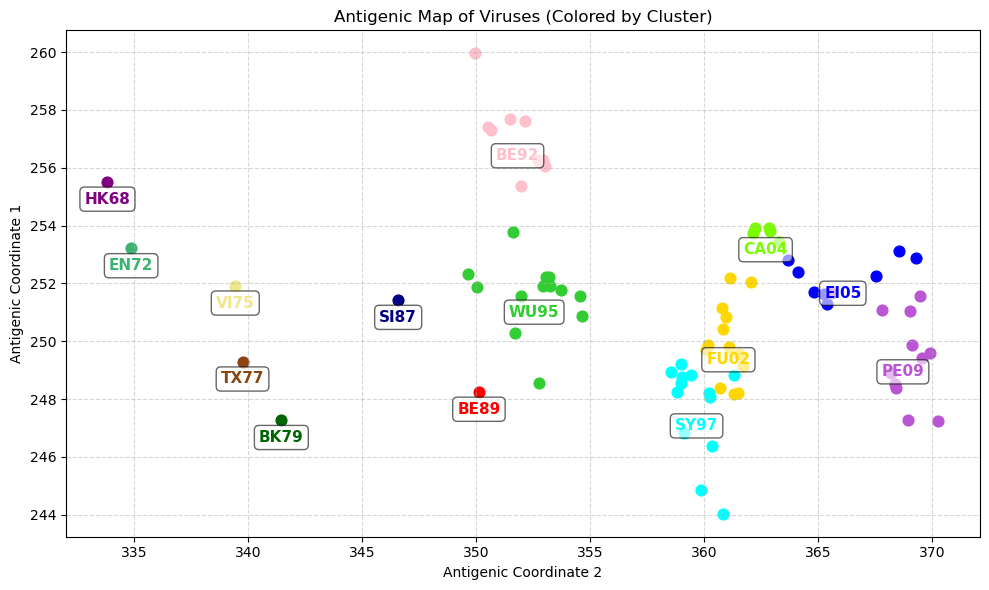

In [22]:
plot_antigenic_map(df_antigenic_map,color_map,unique_clusters)

### 3.Antibody Landscape


#### 3.1: 3d Antibody Landscape: 
3D represntation of the titer for each antigen for each patient

##### Patient1

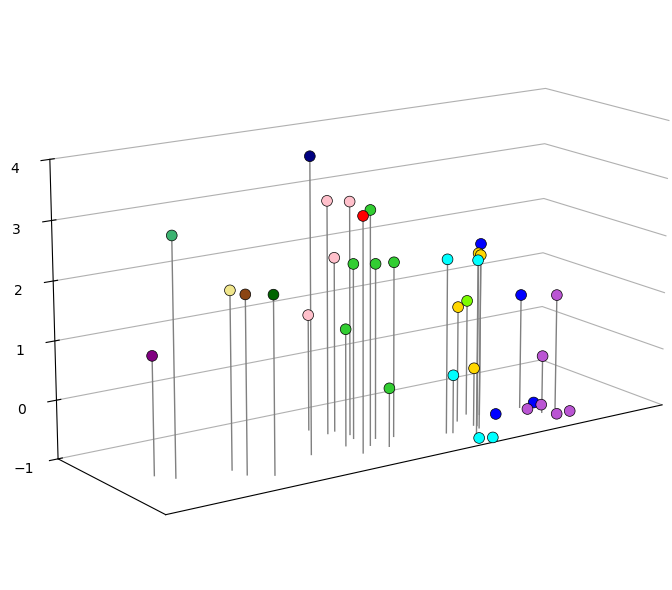

In [23]:
plot_3d_antibody(X,Y,Z,C)

##### Patient 2 (Optional)

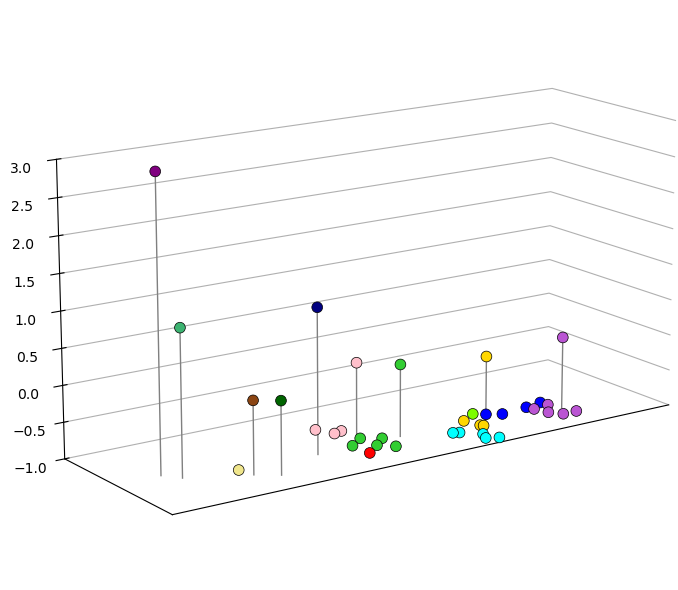

In [24]:
plot_3d_antibody(X_2,Y_2,Z_2,C_2)

### 3.2 Antibody summary path 

Here, we compute a path that passes through the different antigenic clusters. We then plot this path in a 2D visualization, where the X-axis represents the summary path and the Y-axis represents the Titer. A smoothing spline is applied to trace a curve that passes through the different antigenic clusters

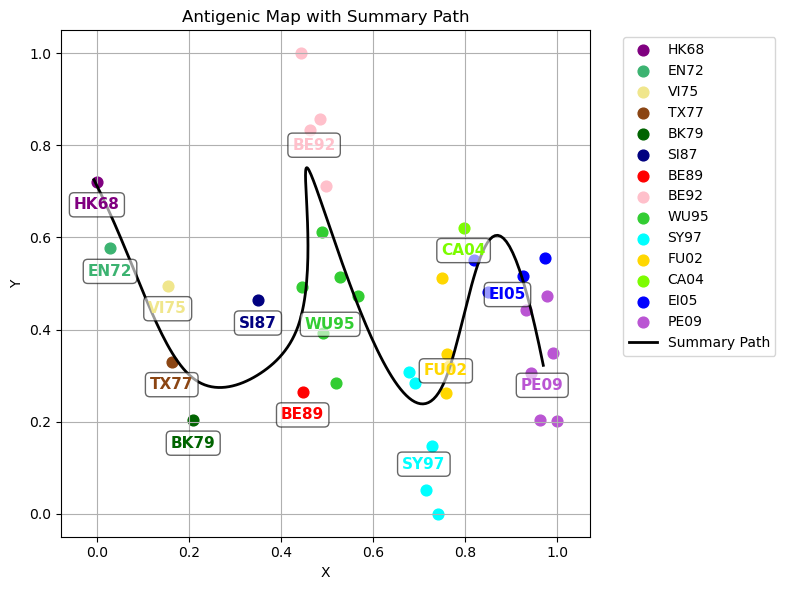

In [25]:
x_smooth,y_smooth,df_centroids=find_summary_path(df_landscape,unique_clusters,SMOOTH_FACTOR)

## 3.3  Antibody Surface


The algorithm for generating the 3D antibody surface map is based on locally weighted linear regression. The main steps are: <br>

	1.	Initialize the Surface Grid  

Create a 2D grid of size N × N, where N is a hyperparameter called GRID_SIZE. <br>

	2.	Compute Antigenic Distances

For each position on the surface, compute the Euclidean distance to each antigen:
$$
a_{ij} = \sqrt{(x_j - x_i)^2 + (y_j - y_i)^2}
$$
If a distance exceeds a threshold value A, its weight is set to zero. Otherwise, use the tricubic weighting function:
$$
w_{ij} =
\begin{cases}
\left(1 - \left(\frac{a_{ij}}{A}\right)^3\right)^3 & \text{if } a_{ij} \leq A \
0 & \text{if } a_{ij} > A
\end{cases}
$$
	3.	Apply Weighted Linear Regression
At each surface position p_j, perform a locally-weighted linear regression using the titers z_i and coordinates x_i, y_i. The regression is defined as:
$$
z_i = c_j + x_i y_i \beta_j + \epsilon_i
$$
where c_j and \beta_j are regression coefficients specific to each location, optimized by minimizing the weighted sum of squared errors:
$$
S = \sum_{i=1}^{n} w_{ij} \cdot \epsilon_i^2
$$
	4.	Predict Titer Values
The predicted titer for each surface position is computed as:
$$
\hat{z}_j = c_j + x_j y_j \beta_j
$$

Each point on the 3D antibody landscape is defined by three coordinates:

- **\( xi \)**: the x-coordinate on the antigenic map  
- **\( yi \)**: the y-coordinate on the antigenic map  
- **\( zi \)**: the log-transformed HI titer, representing antibody strength

#### Patient 1 

the RMSE is :0.95096155412981


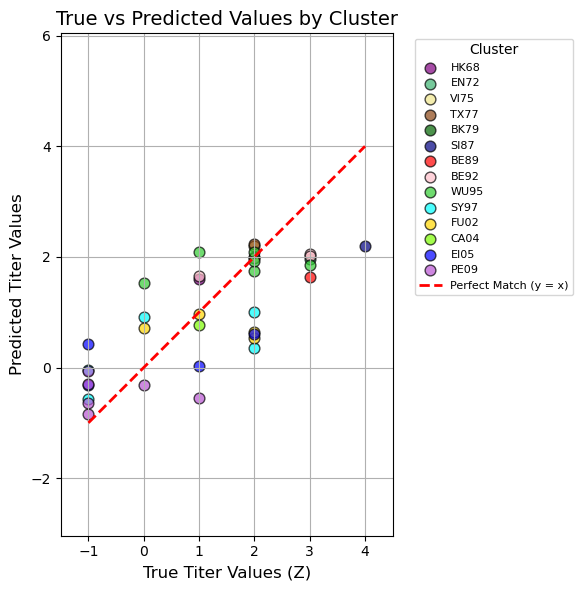

In [26]:
x_range,y_range,landscape_z,predicted_z =compute_surface_regression(X,Y,Z,GRID_SIZE,A,CLOSE_NEIGH,cluster_label,unique_clusters)


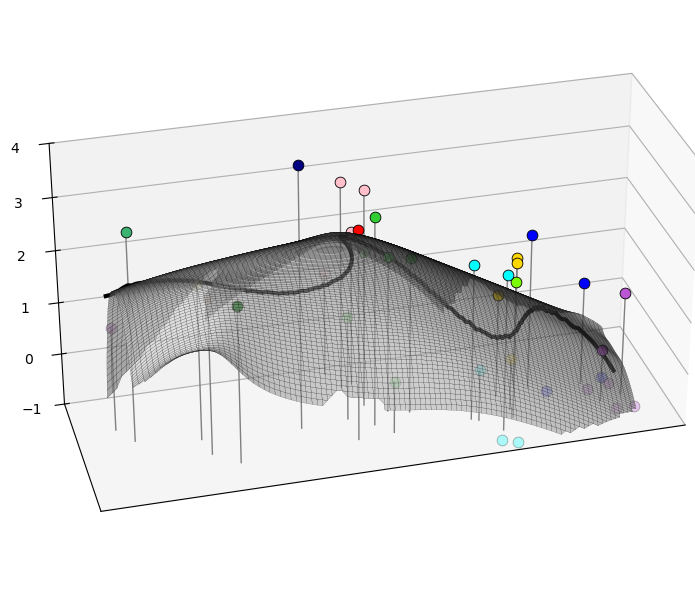

In [27]:
masked_z,x_path_valid,y_path_valid,z_path_valid=plot3d_antibody_surface(X,Y,Z,C,GRID_SIZE,landscape_z,x_range,y_range,x_smooth,y_smooth,unique_clusters,cluster_label)

#### Patient 2 (Optional)

the RMSE is :0.4836085240828659


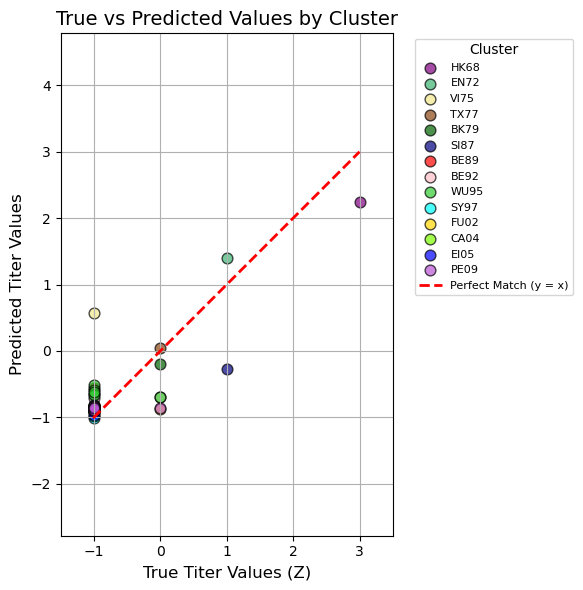

In [28]:
x_range,y_range,landscape_z2,predicted_z2 =compute_surface_regression(X_2,Y_2,Z_2,GRID_SIZE,A,CLOSE_NEIGH,cluster_label,unique_clusters)


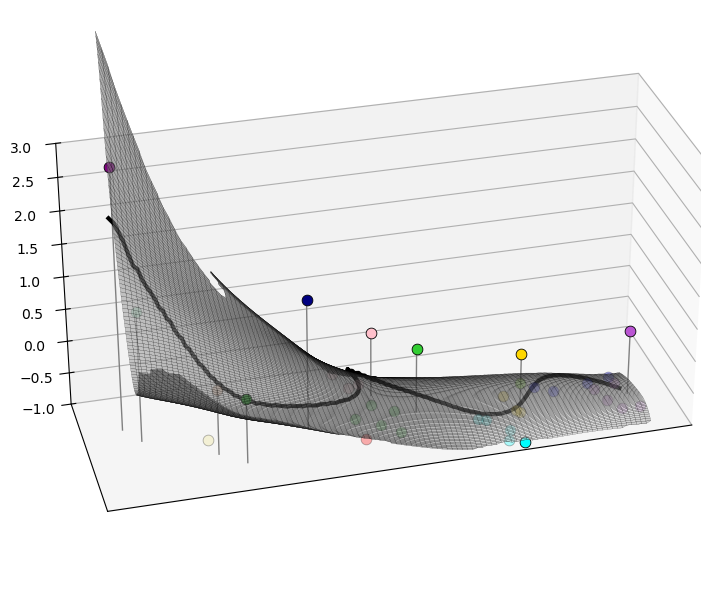

In [29]:
masked_z2,x2_path_valid,y2_path_valid,z2_path_valid=plot3d_antibody_surface(X_2,Y_2,Z_2,C,GRID_SIZE,landscape_z2,x_range,y_range,x_smooth,y_smooth,unique_clusters,cluster_label)

### 4. 2D antibody landscape

#### Patient 1

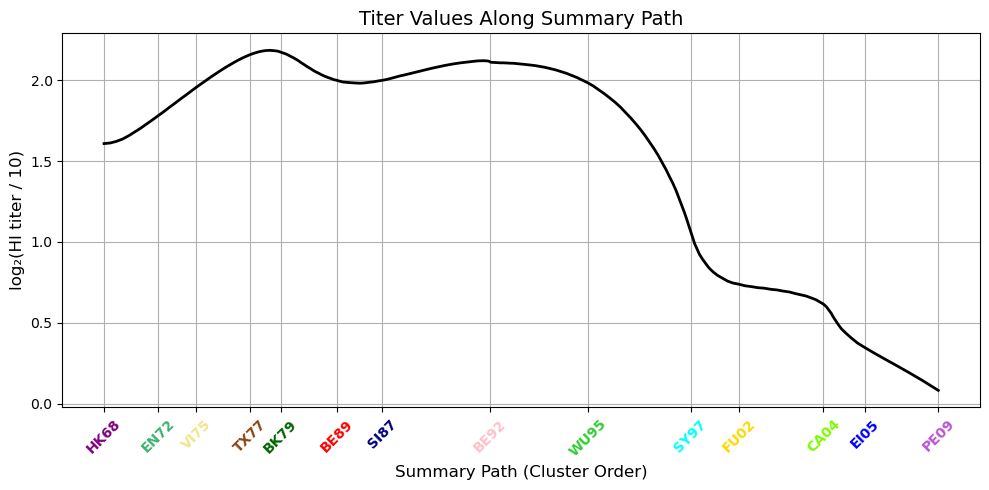

In [30]:
plot_2d_landscape(x_path_valid,y_path_valid,z_path_valid,df_centroids)

#### Patinet 2 (Optional)

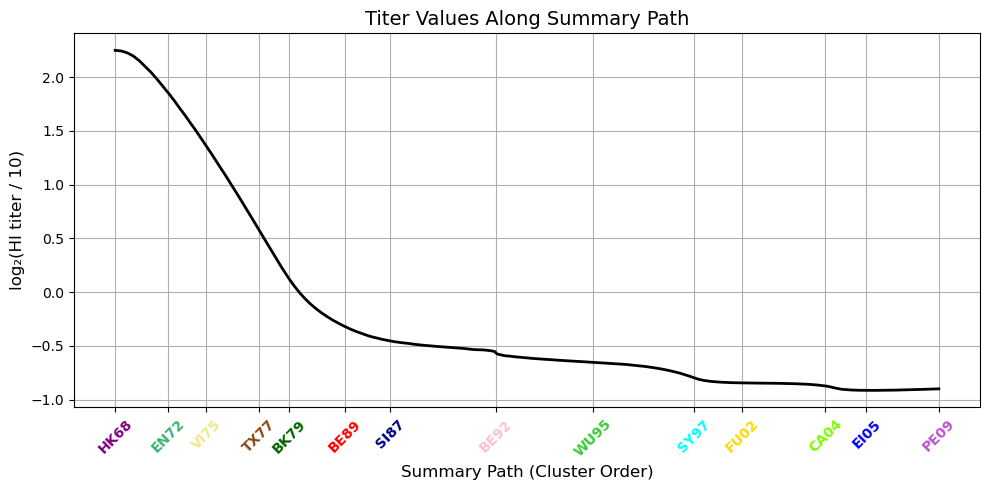

In [31]:
plot_2d_landscape(x2_path_valid,y2_path_valid,z2_path_valid,df_centroids)

#### Compate patients

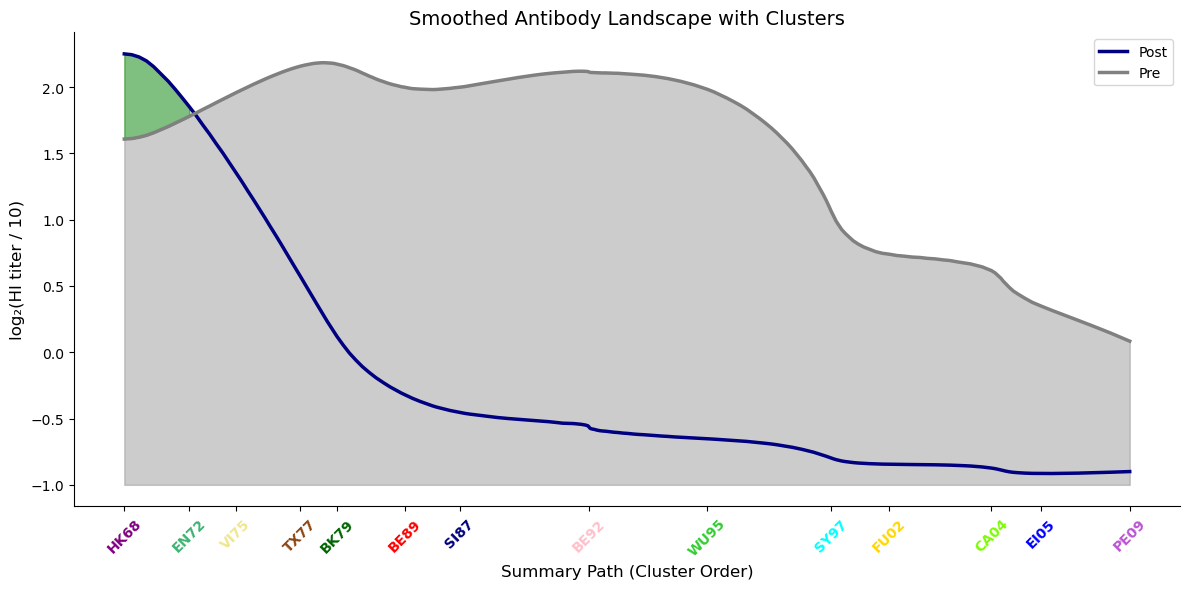

In [32]:
plot_ema_smooth_landscape_with_clusters(x_path_valid, y_path_valid, z_path_valid, z2_path_valid, df_centroids,color_map=color_map ,label_pre="Pre", label_post="Post")